# Heart Disease Prediction using Random Forest

we are going to build a Random Forest classifier to predict heart disease based on various health indicators. 
## What is Heart Disease?

Heart disease describes a range of conditions that affect your heart. Heart diseases include:
- Blood vessel disease, such as coronary artery disease
- Heart rhythm problems (arrhythmias)
- Heart defects you're born with (congenital heart defects)
- Heart valve disease


## Loading and Exploring the Data

Let's load our heart disease dataset and take a look at its structure:

Dataset shape: (918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Missing values in each column:


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Heart Disease distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Percentages:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


## Data Preprocessing

Before we can use the data with our Random Forest model, we need to:
1. Convert categorical variables to numerical values
2. Separate features (X) from the target variable (y)
3. Split the data into training and testing sets

Processed data (first 5 rows):


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


Training set size: 734 samples
Testing set size: 184 samples
Number of features: 11


## Building the Random Forest Model

Now let's create and train our Random Forest classifier with default parameters:

Accuracy of Random Forest classifier: 0.8804 (88.04%)


## Evaluating the Model

Let's take a closer look at how our model performs:

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.90      0.90      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



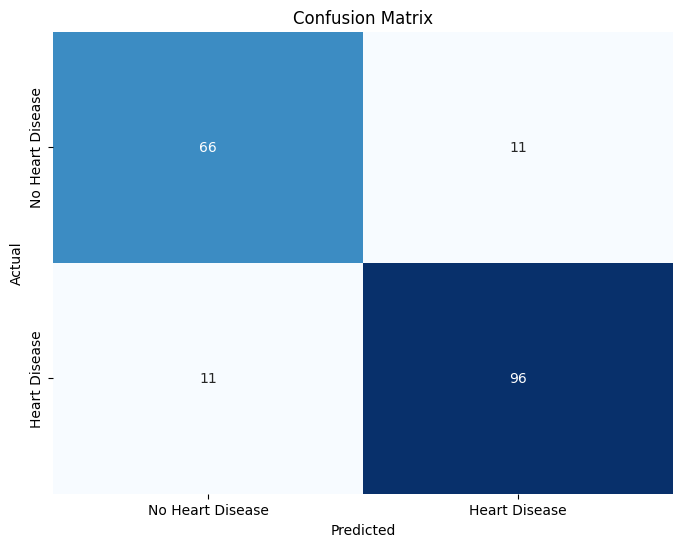

## Hyperparameter Tuning

Let's improve our model by finding the best hyperparameters. We'll use GridSearchCV to systematically try different combinations of parameters:

Parameter grid for GridSearchCV:
  n_estimators: [50, 100, 200]
  max_depth: [None, 10, 20]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 2]

Total combinations to try: 36


Performing grid search. This may take a moment...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters found:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100

Best cross-validation score: 0.8746 (87.46%)


## Evaluating the Tuned Model

Now let's evaluate our model with the best parameters on the test set:

Accuracy of tuned Random Forest classifier: 0.8804 (88.04%)

Comparison:
  Default model accuracy: 0.8804 (88.04%)
  Tuned model accuracy:   0.8804 (88.04%)
  Improvement:            0.0000 (0.00%)


Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        77
           1       0.90      0.89      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



## Making Predictions on New Data

Let's see how to use our trained model to predict heart disease for a new patient:

New patient data:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   55   M           ASY        140          250          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  
0              Y      2.0     Flat  

Processed new patient data (encoded):
   Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0   55    1              0        140          250          0           1   

   MaxHR  ExerciseAngina  Oldpeak  ST_Slope  
0    120               1      2.0         1  

Prediction for new patient:
Heart Disease: Likely

Prediction probabilities:
  No Heart Disease: 0.0118 (1.18%)
  Heart Disease:    0.9882 (98.82%)
